# Exercise 2

In [1]:
import locale

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    locale.setlocale(locale.LC_ALL, 'fr_FR.utf8')
except locale.Error:
    pass

production_data_path = 'edunao-files/Donnees_France_2024_fr_cet.csv'
capacity_data_path = 'edunao-files/Capacites_France_2024.csv'

france_2024_data = pd.read_csv(
    production_data_path,
    sep=';',
    decimal=',',
    index_col=0,
)
france_2024_data.index = pd.to_datetime(france_2024_data.index, utc=True).tz_convert('Europe/Paris')
france_2024_data = france_2024_data.apply(pd.to_numeric, errors='coerce')

installed_capacity_data = pd.read_csv(
    capacity_data_path,
    sep=';',
    decimal=',',
    index_col=0,
)
installed_capacity_data.index = pd.to_datetime(installed_capacity_data.index, utc=True).tz_convert('Europe/Paris')
installed_capacity_data = installed_capacity_data.apply(pd.to_numeric, errors='coerce')

source_columns = {
    'Wind Onshore': 'Onshore wind',
    'Solar': 'Solar PV',
    'Hydro Run-of-river and poundage': 'Run-of-river hydro',
    'Fossil Gas': 'Gas',
    'Fossil Oil': 'Oil',
    'Nuclear': 'Nuclear',
}

fatal_source_columns = [
    'Wind Onshore',
    'Solar',
    'Hydro Run-of-river and poundage',
]

production_mw = france_2024_data[list(source_columns.keys())].rename(columns=source_columns)
gross_consumption_mw = france_2024_data['Load']
number_of_hours = len(france_2024_data)

Month = mdates.MonthLocator(bymonthday=1)
MonthFmt = mdates.DateFormatter('%b')

## 2.1 Question

Calculate the annual energy produced by each production technology and their relative proportions in the production mix. The technologies studied are onshore wind, solar PV, run-of-river hydro, gas, oil, and nuclear.

In [2]:
# The data are hourly average powers in MW, so summing over the year gives MWh.
annual_energy_mwh = production_mw.sum()
annual_energy_twh = annual_energy_mwh / 1_000_000
studied_mix_share = annual_energy_twh / annual_energy_twh.sum() * 100

annual_production_results = pd.DataFrame(
    {
        'Annual energy (TWh)': annual_energy_twh,
        'Share in studied mix (%)': studied_mix_share,
    }
).round(2)

display(annual_production_results)

print('Comment:')
print('- Nuclear generation dominates the studied production mix in 2024.')
print('- Run-of-river hydro and onshore wind are the next largest contributors among the selected sources.')
print('- Gas and oil contribute much less energy over the year, which is consistent with their flexible or backup role.')

,Annual energy (TWh),Share in studied mix (%)
Onshore wind,41.91,8.56
Solar PV,23.32,4.76
Run-of-river hydro,45.89,9.37
Gas,17.23,3.52
Oil,1.39,0.28
Nuclear,360.10,73.51


Comment:
- Nuclear generation dominates the studied production mix in 2024.
- Run-of-river hydro and onshore wind are the next largest contributors among the selected sources.
- Gas and oil contribute much less energy over the year, which is consistent with their flexible or backup role.


## 2.2 Question

Calculate the capacity factors of the production sources, defined by

\[
f_c = \frac{\text{annual energy produced}}{\text{installed capacity} \times \text{number of hours in the year}}.
\]

The installed capacities are provided in `Capacites_France_2024.csv`. Comment on the values obtained.

,Annual energy (TWh),Installed capacity (MW),Capacity factor (%)
Onshore wind,41.91,22134.0,21.56
Solar PV,23.32,17419.0,15.24
Run-of-river hydro,45.89,11598.0,45.05
Gas,17.23,13133.0,14.93
Oil,1.39,3042.0,5.22
Nuclear,360.10,61370.0,66.80


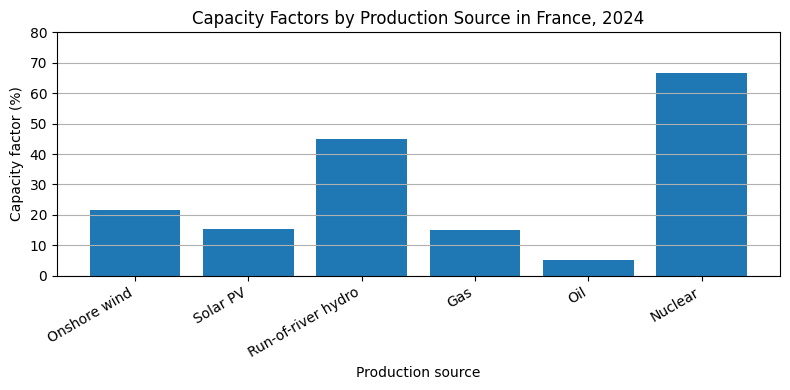

Comment:
- Nuclear has the highest capacity factor among the selected sources because it is operated for many hours of the year.
- Run-of-river hydro has a relatively high value because river flow is often available, although not fully controllable.
- Solar PV is limited by daylight and weather, while onshore wind depends on wind conditions.
- Gas and oil have low capacity factors because they mainly provide flexibility and peak support.


In [3]:
installed_capacity_mw = installed_capacity_data.iloc[0][list(source_columns.keys())].rename(index=source_columns)

capacity_factor = annual_energy_mwh / (installed_capacity_mw * number_of_hours)
capacity_factor_percent = capacity_factor * 100

capacity_factor_results = pd.DataFrame(
    {
        'Annual energy (TWh)': annual_energy_twh,
        'Installed capacity (MW)': installed_capacity_mw,
        'Capacity factor (%)': capacity_factor_percent,
    }
).round(2)

display(capacity_factor_results)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(capacity_factor_percent.index, capacity_factor_percent.values)
plt.title('Capacity Factors by Production Source in France, 2024')
plt.xlabel('Production source')
plt.ylabel('Capacity factor (%)')
ax.set_ylim(0, 80)
plt.xticks(rotation=30, ha='right')
plt.grid(True, axis='y')
fig.tight_layout()
fig.savefig('figures/exercise_2-2.pdf')
plt.show()

print('Comment:')
print('- Nuclear has the highest capacity factor among the selected sources because it is operated for many hours of the year.')
print('- Run-of-river hydro has a relatively high value because river flow is often available, although not fully controllable.')
print('- Solar PV is limited by daylight and weather, while onshore wind depends on wind conditions.')
print('- Gas and oil have low capacity factors because they mainly provide flexibility and peak support.')

## 2.3 Question

Net consumption is defined as

\[
\text{net consumption} = \text{gross consumption} - \text{must-run production}.
\]

Plot net consumption as a function of time, considering onshore wind, solar PV, and run-of-river hydro as must-run production.

,Gross consumption (GW),Must-run production (GW),Net consumption (GW)
mean,48.92,12.65,36.27
max,82.80,31.46,73.20
min,29.58,3.86,15.13


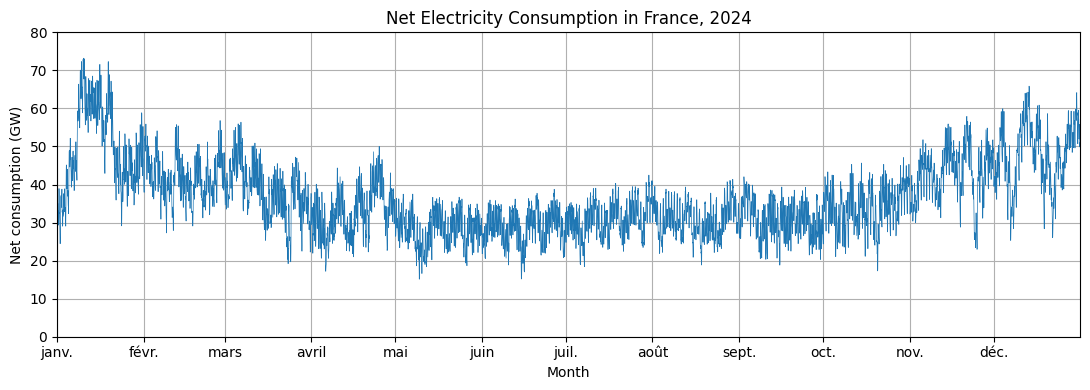

Comment:
- Average gross consumption is 48.9 GW.
- Average must-run production is 12.7 GW.
- Average net consumption is 36.3 GW.
- The remaining demand must be supplied by dispatchable generation, storage, or imports in a real system.


In [4]:
must_run_production_mw = france_2024_data[fatal_source_columns].fillna(0).sum(axis=1)
net_consumption_mw = gross_consumption_mw - must_run_production_mw

net_consumption_summary = pd.DataFrame(
    {
        'Gross consumption (GW)': gross_consumption_mw / 1000,
        'Must-run production (GW)': must_run_production_mw / 1000,
        'Net consumption (GW)': net_consumption_mw / 1000,
    }
).agg(['mean', 'max', 'min']).round(2)

display(net_consumption_summary)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(net_consumption_mw.index, net_consumption_mw.values / 1000, linewidth=.5)
plt.title('Net Electricity Consumption in France, 2024')
ax.set_xlim(net_consumption_mw.index[0], net_consumption_mw.index[-1])
ax.xaxis.set_major_locator(Month)
ax.xaxis.set_major_formatter(MonthFmt)
plt.xlabel('Month')
ax.set_ylim(0, 80)
plt.ylabel('Net consumption (GW)')
plt.grid(True)
fig.tight_layout()
fig.savefig('figures/exercise_2-3.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(gross_consumption_mw.index, gross_consumption_mw.values / 1000, linewidth=.5, label='Gross consumption')
ax.plot(net_consumption_mw.index, net_consumption_mw.values / 1000, linewidth=.5, label='Net consumption')
plt.title('Gross and Net Electricity Consumption in France, 2024')
ax.set_xlim(gross_consumption_mw.index[0], gross_consumption_mw.index[-1])
ax.xaxis.set_major_locator(Month)
ax.xaxis.set_major_formatter(MonthFmt)
plt.xlabel('Month')
ax.set_ylim(0, 100)
plt.ylabel('Power (GW)')
plt.grid(True)
plt.legend()
fig.tight_layout()
fig.savefig('figures/exercise_2-3_gross_net.pdf')
plt.show()

print('Comment:')
print(f'- Average gross consumption is {gross_consumption_mw.mean() / 1000:.1f} GW.')
print(f'- Average must-run production is {must_run_production_mw.mean() / 1000:.1f} GW.')
print(f'- Average net consumption is {net_consumption_mw.mean() / 1000:.1f} GW.')
print('- The remaining demand must be supplied by dispatchable generation, storage, or imports in a real system.')

## 2.4 Question

Plot the load duration curve of net consumption together with the load duration curve of total consumption.

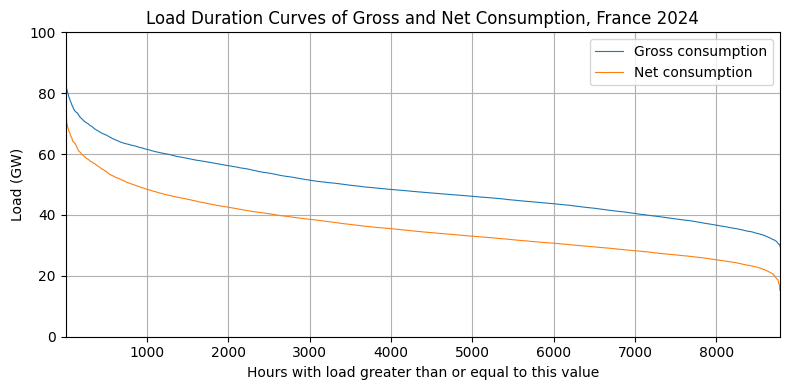

Comment:
- The net load duration curve is below the gross load duration curve because must-run renewable production reduces residual demand.
- The average reduction is 12.7 GW, or 25.9% of average gross consumption.
- The vertical gap is not constant because wind and solar generation vary over time.
- This curve is the relevant demand profile for sizing dispatchable generation in the simplified model.


In [5]:
gross_duration_gw = gross_consumption_mw.sort_values(ascending=False).reset_index(drop=True) / 1000
net_duration_gw = net_consumption_mw.sort_values(ascending=False).reset_index(drop=True) / 1000
duration_hours = np.arange(1, len(gross_duration_gw) + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(duration_hours, gross_duration_gw.values, linewidth=.8, label='Gross consumption')
ax.plot(duration_hours, net_duration_gw.values, linewidth=.8, label='Net consumption')
plt.title('Load Duration Curves of Gross and Net Consumption, France 2024')
ax.set_xlim(1, len(gross_duration_gw))
plt.xlabel('Hours with load greater than or equal to this value')
ax.set_ylim(0, 100)
plt.ylabel('Load (GW)')
plt.grid(True)
plt.legend()
fig.tight_layout()
fig.savefig('figures/exercise_2-4.pdf')
plt.show()

average_reduction_mw = gross_consumption_mw.mean() - net_consumption_mw.mean()
average_reduction_percent = average_reduction_mw / gross_consumption_mw.mean() * 100

print('Comment:')
print('- The net load duration curve is below the gross load duration curve because must-run renewable production reduces residual demand.')
print(f'- The average reduction is {average_reduction_mw / 1000:.1f} GW, or {average_reduction_percent:.1f}% of average gross consumption.')
print('- The vertical gap is not constant because wind and solar generation vary over time.')
print('- This curve is the relevant demand profile for sizing dispatchable generation in the simplified model.')